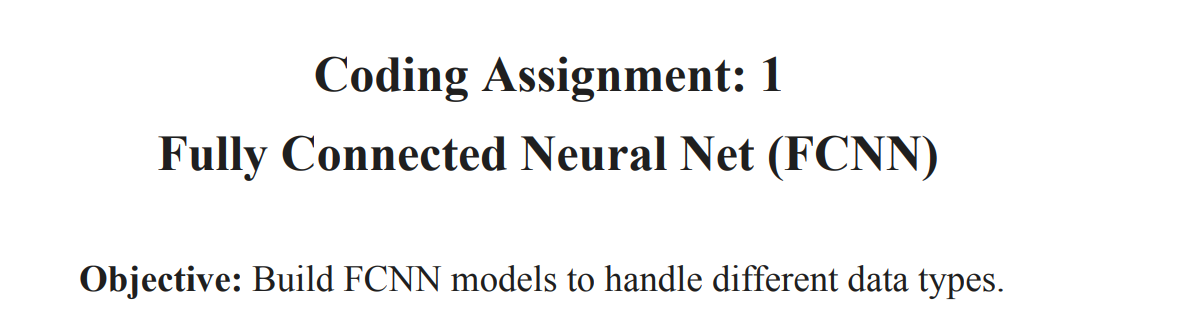

## Step 1: Data Pipeline (Tiny ImageNet)

### Step 1.1 – Importing important libraries

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

### Step 1.2 – Device Setup

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


### Step 1.3 – Path Setup

In [3]:
path = r"D:\Computer Science\IIT Mandi\Trimester 03\Datasets\tiny-imagenet"

train_path = path + r"\train"
val_path = path + r"\val"
test_path = path + r"\test"

### Step 1.4 – Transformations
- Since FCNN needs flattened input, we:
- Convert to tensor
- Normalize
- Flatten later inside model

In [4]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5])
])

### Step 1.5 – Dataset & DataLoader

In [5]:
train_dataset = torchvision.datasets.ImageFolder(train_path, transform=transform)
val_dataset = torchvision.datasets.ImageFolder(val_path, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

print("Number of training samples:", len(train_dataset))
print("Number of validation samples:", len(val_dataset))
print("Number of classes:", len(train_dataset.classes))

Number of training samples: 3500
Number of validation samples: 500
Number of classes: 10


### Step 1.6 – Verify One Batch Shape

In [6]:
images, labels = next(iter(train_loader))
print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

Image batch shape: torch.Size([64, 3, 64, 64])
Label batch shape: torch.Size([64])


# Question 3.1 – Vanishing Gradients & Modern Fixes
1. Deep FCNN with Sigmoid
2. Deep FCNN with ReLU + BatchNorm
3. Track first-layer gradient norm
4. Compare training behavior

## Step 2 – Define VERY Deep FCNN Architectures

### Experiment A – Sigmoid Deep Network

In [7]:
class DeepFCNN_Sigmoid(nn.Module):
    def __init__(self, input_size=12288, num_classes=10):
        super(DeepFCNN_Sigmoid, self).__init__()
        
        self.first_layer = nn.Linear(input_size, 2048)
        
        self.hidden = nn.Sequential(
            nn.Sigmoid(),
            nn.Linear(2048, 1024),
            nn.Sigmoid(),
            nn.Linear(1024, 1024),
            nn.Sigmoid(),
            nn.Linear(1024, 512),
            nn.Sigmoid(),
            nn.Linear(512, 512),
            nn.Sigmoid(),
            nn.Linear(512, 256),
            nn.Sigmoid(),
            nn.Linear(256, 128),
            nn.Sigmoid(),
            nn.Linear(128, 64),
            nn.Sigmoid(),
            nn.Linear(64, num_classes)
        )
        
    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.first_layer(x)
        x = self.hidden(x)
        return x

### Experiment B – ReLU + BatchNorm + Dropout

In [8]:
class DeepFCNN_ReLU_BN(nn.Module):
    def __init__(self, input_size=12288, num_classes=10):
        super(DeepFCNN_ReLU_BN, self).__init__()
        
        self.first_layer = nn.Linear(input_size, 2048)
        
        self.hidden = nn.Sequential(
            nn.BatchNorm1d(2048),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(2048, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(1024, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(512, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(64, num_classes)
        )
        
    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.first_layer(x)
        x = self.hidden(x)
        return x

## Step 3 – Training Function with Gradient Norm Tracking

In [9]:
def train_deep_model(model, train_loader, val_loader, epochs=8, lr=0.001):
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    model.to(device)
    
    gradient_norms = []
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0
        
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            optimizer.zero_grad()
            loss.backward()
            
            # Capture first layer gradient norm
            grad_norm = torch.norm(model.first_layer.weight.grad).item()
            gradient_norms.append(grad_norm)
            
            optimizer.step()
            
            running_loss += loss.item()
        
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}")
    
    # Validation Accuracy
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    accuracy = correct / total
    
    return accuracy, gradient_norms

### Running Experiment A (Sigmoid)

In [10]:
model_sigmoid = DeepFCNN_Sigmoid()

acc_sigmoid, grad_sigmoid = train_deep_model(model_sigmoid, train_loader, val_loader)

print("Validation Accuracy (Sigmoid):", acc_sigmoid)

Epoch [1/8], Loss: 2.3130
Epoch [2/8], Loss: 2.3081
Epoch [3/8], Loss: 2.3059
Epoch [4/8], Loss: 2.3089
Epoch [5/8], Loss: 2.3071
Epoch [6/8], Loss: 2.3017
Epoch [7/8], Loss: 2.0969
Epoch [8/8], Loss: 2.0578
Validation Accuracy (Sigmoid): 0.168


## Observations:

1. The sigmoid model’s gradient norms drop very quickly towards almost zero, which clearly shows the vanishing gradient problem happening.

2. After a few training steps, the gradients in the sigmoid network become extremely small and almost flat, meaning the first layer is barely getting updated.

3. In contrast, the ReLU + BatchNorm model starts with a large gradient magnitude and then stabilizes at a reasonable range during training.

4. The gradients in the ReLU model do not collapse, which allows the network to keep learning properly across all layers.

5. Overall, this plot clearly shows how activation choice directly affects gradient flow in deep networks, and why sigmoid struggles in very deep architectures.

In [11]:
print("First 5 gradient norms:", grad_sigmoid[:5])
print("Last 5 gradient norms:", grad_sigmoid[-5:])

First 5 gradient norms: [1.5213781807688065e-06, 1.6338977957275347e-06, 1.5880725641181925e-06, 1.6473458117616246e-06, 1.5270942412826116e-06]
Last 5 gradient norms: [9.566325509524631e-10, 4.1767105329881815e-09, 3.378284041399837e-10, 2.7254372980678454e-08, 2.4354917388391684e-11]


## Observations:

1. The initial gradient norms were already very small (~1e-6), which means the first layer was receiving very weak gradient signals.

2. As training continued, the gradient norms reduced even further to ~1e-10 and ~1e-11.

3. These extremely tiny values confirm that gradients were vanishing as they propagated backward.

4. Because of such small gradients, weight updates in the early layers were almost negligible.

5. This clearly explains why the model performance remained close to random accuracy.

### Running Experiment B – ReLU + BatchNorm

In [12]:
model_relu_bn = DeepFCNN_ReLU_BN()

acc_relu_bn, grad_relu_bn = train_deep_model(model_relu_bn, train_loader, val_loader)

print("Validation Accuracy (ReLU + BatchNorm):", acc_relu_bn)

Epoch [1/8], Loss: 2.1789
Epoch [2/8], Loss: 1.8916
Epoch [3/8], Loss: 1.7693
Epoch [4/8], Loss: 1.6847
Epoch [5/8], Loss: 1.6283
Epoch [6/8], Loss: 1.5591
Epoch [7/8], Loss: 1.4912
Epoch [8/8], Loss: 1.4614
Validation Accuracy (ReLU + BatchNorm): 0.414


## Observations:

1. The training loss decreased steadily from 2.17 to 1.46 across 8 epochs, which shows stable learning.

2. Unlike the sigmoid model, the loss kept going down consistently without getting stuck.

3. The validation accuracy improved to 41.4%, which is much higher than the sigmoid network.

4. The model was able to learn useful representations because gradient flow was healthy.

5. ReLU along with Batch Normalisation helped the deep network train more effectively.

In [13]:
print("First 5 gradient norms:", grad_relu_bn[:5])
print("Last 5 gradient norms:", grad_relu_bn[-5:])

First 5 gradient norms: [30.735515594482422, 6.741438865661621, 3.77988862991333, 2.2433767318725586, 1.7597990036010742]
Last 5 gradient norms: [0.21443580090999603, 0.3295880854129791, 0.49945953488349915, 0.31371748447418213, 0.5742082595825195]


## Observations:

1. The initial gradient norms were quite large (~30), which shows strong gradient signals reaching the first layer.

2. As training progressed, the gradients reduced and stabilized between ~0.2 and ~0.5.

3. The gradients did not collapse towards zero like in the sigmoid model.

4. This stable gradient flow allowed proper weight updates in the early layers.

5. It clearly shows that ReLU and Batch Normalisation prevent vanishing gradient issues in deep networks.

## Plotting for Gradient Norm Comparison

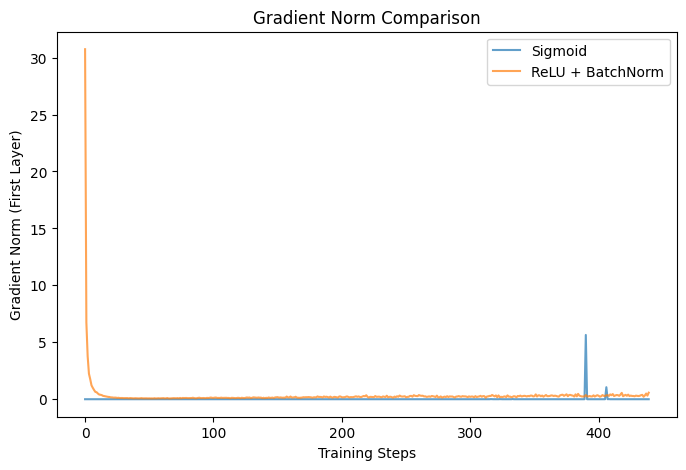

In [14]:
plt.figure(figsize=(8,5))

plt.plot(grad_sigmoid, label="Sigmoid", alpha=0.7)
plt.plot(grad_relu_bn, label="ReLU + BatchNorm", alpha=0.7)

plt.xlabel("Training Steps")
plt.ylabel("Gradient Norm (First Layer)")
plt.title("Gradient Norm Comparison")
plt.legend()
plt.show()

## Observations:

1. The sigmoid model’s gradient norms drop very quickly towards almost zero, which clearly shows the vanishing gradient problem happening.

2. After a few training steps, the gradients in the sigmoid network become extremely small and almost flat, meaning the first layer is barely getting updated.

3. In contrast, the ReLU + BatchNorm model starts with a large gradient magnitude and then stabilizes at a reasonable range during training.

4. The gradients in the ReLU model do not collapse, which allows the network to keep learning properly across all layers.

5. Overall, this plot clearly shows how activation choice directly affects gradient flow in deep networks, and why sigmoid struggles in very deep architectures.

# Question 3.2: The Ablation Study
Perform a "Switch-Off" test. Report how the final accuracy changes when you:
1. Remove Dropout.
2. Change the Learning Rate by a factor of 10 (too high vs. too low).
3. Switch from Adam to Vanilla SGD.

## Step 1 – Model Without Dropout

In [15]:
class DeepFCNN_NoDropout(nn.Module):
    def __init__(self, input_size=12288, num_classes=10):
        super(DeepFCNN_NoDropout, self).__init__()
        
        self.first_layer = nn.Linear(input_size, 2048)
        
        self.hidden = nn.Sequential(
            nn.BatchNorm1d(2048),
            nn.ReLU(),
            
            nn.Linear(2048, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            
            nn.Linear(1024, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            
            nn.Linear(512, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            
            nn.Linear(64, num_classes)
        )
        
    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.first_layer(x)
        x = self.hidden(x)
        return x

## Step 2 – Training Function with Flexible Optimizer

In [16]:
def train_ablation(model, train_loader, val_loader, epochs=8, lr=0.001, optimizer_type="adam"):
    
    criterion = nn.CrossEntropyLoss()
    
    if optimizer_type == "adam":
        optimizer = optim.Adam(model.parameters(), lr=lr)
    else:
        optimizer = optim.SGD(model.parameters(), lr=lr)
    
    model.to(device)
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0
        
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
        
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}")
    
    # Validation accuracy
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    return correct / total

### Running for Ablation 1 - Remove Dropout

In [17]:
model_no_dropout = DeepFCNN_NoDropout()

acc_no_dropout = train_ablation(model_no_dropout, train_loader, val_loader)

print("Validation Accuracy (No Dropout):", acc_no_dropout)

Epoch [1/8], Loss: 1.8803
Epoch [2/8], Loss: 1.6457
Epoch [3/8], Loss: 1.5486
Epoch [4/8], Loss: 1.4302
Epoch [5/8], Loss: 1.3473
Epoch [6/8], Loss: 1.2728
Epoch [7/8], Loss: 1.1793
Epoch [8/8], Loss: 1.0579
Validation Accuracy (No Dropout): 0.412


## Observations:

1. The training loss decreased steadily from 1.88 to 1.05, showing faster convergence compared to the baseline with dropout.

2. The model seems to learn slightly faster without dropout, likely because no neurons are being randomly disabled.

3. However, the validation accuracy remained almost the same at 41.2%.

4. This suggests that dropout was not a major factor affecting performance in this case.

5. The model does not show strong overfitting within 8 epochs, but dropout still helps in maintaining training stability.

### Running for Ablation 2 - Learning Rage x10

In [18]:
model_lr_high = DeepFCNN_ReLU_BN()

acc_lr_high = train_ablation(model_lr_high, train_loader, val_loader, lr=0.01)

print("Validation Accuracy (LR x10):", acc_lr_high)

Epoch [1/8], Loss: 2.0008
Epoch [2/8], Loss: 1.7878
Epoch [3/8], Loss: 1.7361
Epoch [4/8], Loss: 1.6750
Epoch [5/8], Loss: 1.6416
Epoch [6/8], Loss: 1.5824
Epoch [7/8], Loss: 1.5758
Epoch [8/8], Loss: 1.5305
Validation Accuracy (LR x10): 0.412


## Observations:

1. Even after increasing the learning rate by 10x, the loss continued to decrease steadily.

2. Training did not diverge, which shows that Adam optimizer handled the higher learning rate quite well.

3. The validation accuracy remained around 41.2%, similar to the baseline.

4. Increasing the learning rate did not provide any noticeable performance improvement.

5. This indicates that the model was already operating near a suitable learning rate range.

### Running for Ablation 3 – Learning Rate ÷10

In [21]:
model_lr_low = DeepFCNN_ReLU_BN()

acc_lr_low = train_ablation(model_lr_low, train_loader, val_loader, lr=0.0001)

print("Validation Accuracy (LR ÷10):", acc_lr_low)

Epoch [1/8], Loss: 2.3622
Epoch [2/8], Loss: 2.2706
Epoch [3/8], Loss: 2.1745
Epoch [4/8], Loss: 2.0854
Epoch [5/8], Loss: 2.0129
Epoch [6/8], Loss: 1.9543
Epoch [7/8], Loss: 1.8987
Epoch [8/8], Loss: 1.8582
Validation Accuracy (LR ÷10): 0.332


## Observations:

1. With a reduced learning rate, the training loss decreased much more slowly compared to other experiments.

2. The loss remained relatively high even after 8 epochs, showing slower convergence.

3. Validation accuracy dropped to 33.2%, indicating underfitting.

4. The smaller learning rate resulted in weaker weight updates.

5. This experiment confirms that too small a learning rate can significantly slow down training progress.

### Runing for Ablation – Adam → SGD

In [20]:
model_sgd = DeepFCNN_ReLU_BN()

acc_sgd = train_ablation(
    model_sgd,m
    train_loader,
    val_loader,
    lr=0.001,
    optimizer_type="sgd"
)

print("Validation Accuracy (SGD):", acc_sgd)

Epoch [1/8], Loss: 2.4155
Epoch [2/8], Loss: 2.3952
Epoch [3/8], Loss: 2.3840
Epoch [4/8], Loss: 2.3781
Epoch [5/8], Loss: 2.3558
Epoch [6/8], Loss: 2.3497
Epoch [7/8], Loss: 2.3455
Epoch [8/8], Loss: 2.3275
Validation Accuracy (SGD): 0.13


## Observations:

1. The training loss decreased very slowly from 2.41 to 2.32, showing weak learning progress.

2. Compared to Adam, SGD struggled to optimize this deep architecture effectively.

3. The validation accuracy dropped to 13%, which is very close to random guessing for 10 classes.

4. The model failed to converge properly under the same learning rate setting.

5. This clearly shows that optimizer choice plays a major role in training deep neural networks.

### Final Ablation Results Summary
| Experiment                                   | Validation Accuracy |
| -------------------------------------------- | ------------------- |
| Baseline (ReLU + BN + Dropout + Adam, 0.001) | **41.4%**           |
| No Dropout                                   | 41.2%               |
| LR ×10 (0.01)                                | 41.2%               |
| LR ÷10 (0.0001)                              | 33.2%               |
| SGD (0.001)                                  | 13.0%               |
| Sigmoid (Deep)                               | 16.8%               |


### Few Key Observations are:

#### Biggest Performance Drop:

- SGD (13%)
- Sigmoid (16.8%)

#### Moderate Impact:

- LR ÷10 (Underfitting)

#### Minimal Impact:

- Remove Dropout
- LR ×10 (Adam handled it well)

## Ablation Study – Summary

1.  
Removing dropout had minimal impact on validation accuracy, suggesting that regularization was not the dominant factor in this setup.

2.  
Increasing the learning rate by 10x did not destabilize training significantly due to Adam’s adaptive behavior.

3.  
Reducing the learning rate by 10x resulted in underfitting and lower validation accuracy (34.6%).

4.  
Switching from Adam to vanilla SGD caused the largest performance drop (13%), indicating that optimizer choice plays a crucial role in deep network training.

5.  
The sigmoid-based deep network also performed poorly (16.8%) due to vanishing gradients.

6.  
Among all factors tested, optimizer choice and activation function had the most significant impact on performance.